--- 1. Memulai Analisis Statistika Deskriptif ---
Statistika Deskriptif Data Awal:
       Jumlah kendaraan bermotor  PDB per Kapita        IPM  Panjang Jalan  \
count               3.400000e+01       34.000000  34.000000      34.000000   
mean                4.620015e+06    81941.823529  72.906176   15679.470588   
std                 6.505167e+06    61904.718079   3.426929   10402.934447   
min                 1.924350e+05    23078.000000  66.160000    4449.000000   
25%                 1.135204e+06    48233.250000  71.000000    7403.250000   
50%                 2.666402e+06    64109.500000  72.785000   13209.500000   
75%                 4.188368e+06    77359.000000  73.747500   22143.250000   
max                 2.402367e+07   322619.000000  82.460000   42466.000000   

       Gini Rasio  Kepadatan Penduduk  
count   34.000000           34.000000  
mean     0.344324          752.647059  
std      0.046847         2749.123165  
min      0.245000           10.000000  
25%      0.314

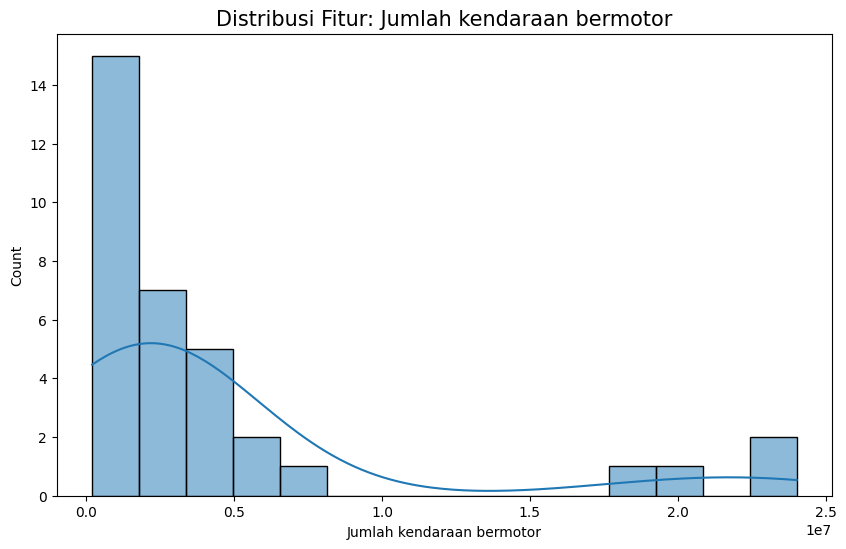

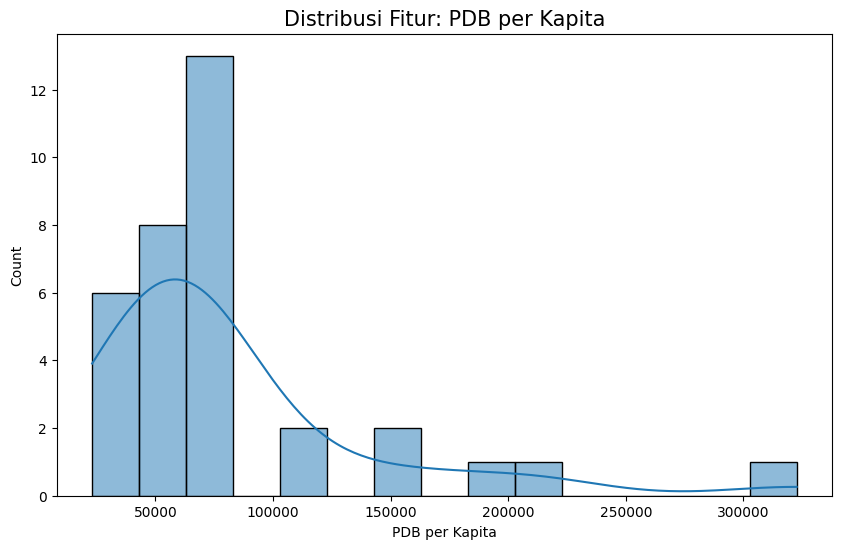

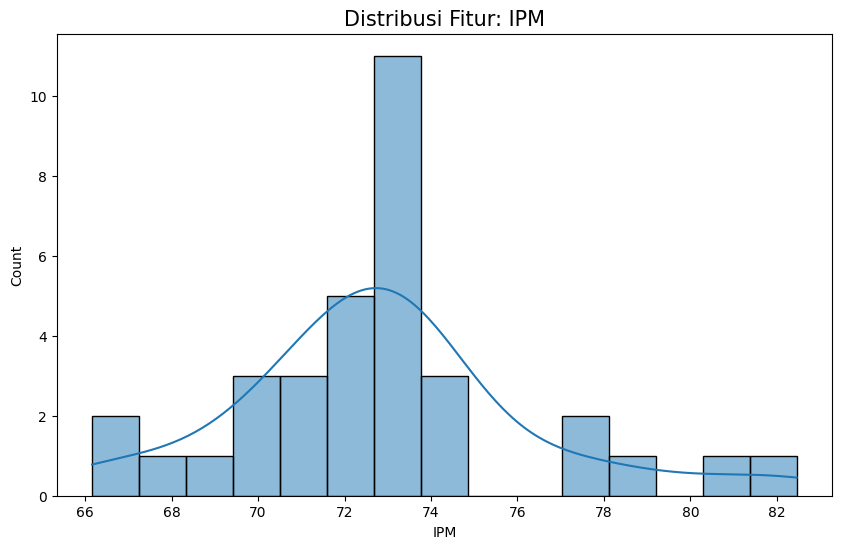

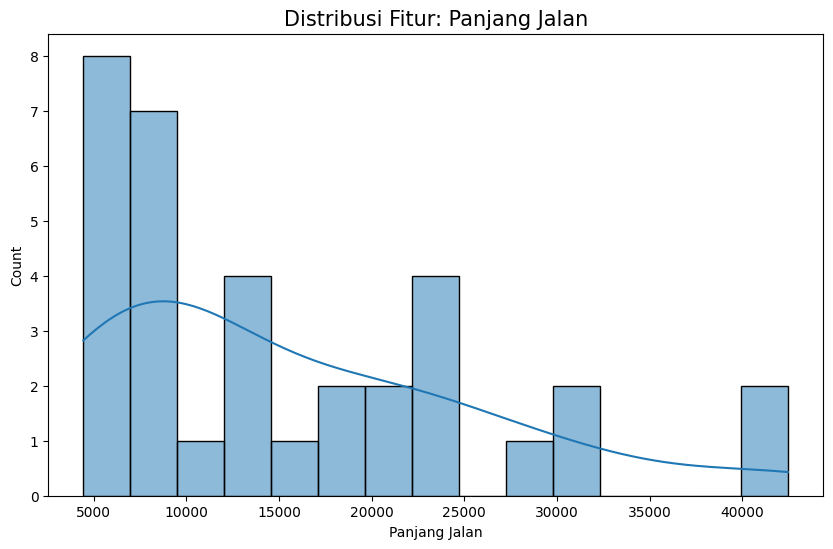

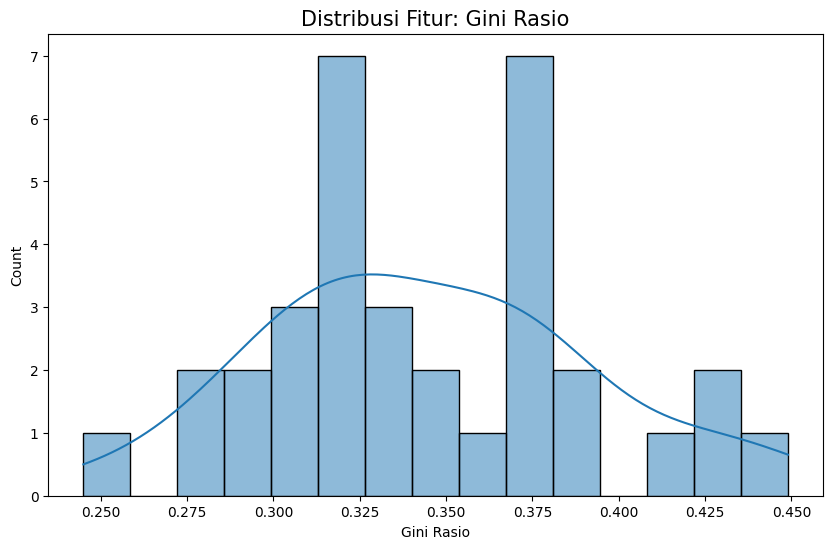

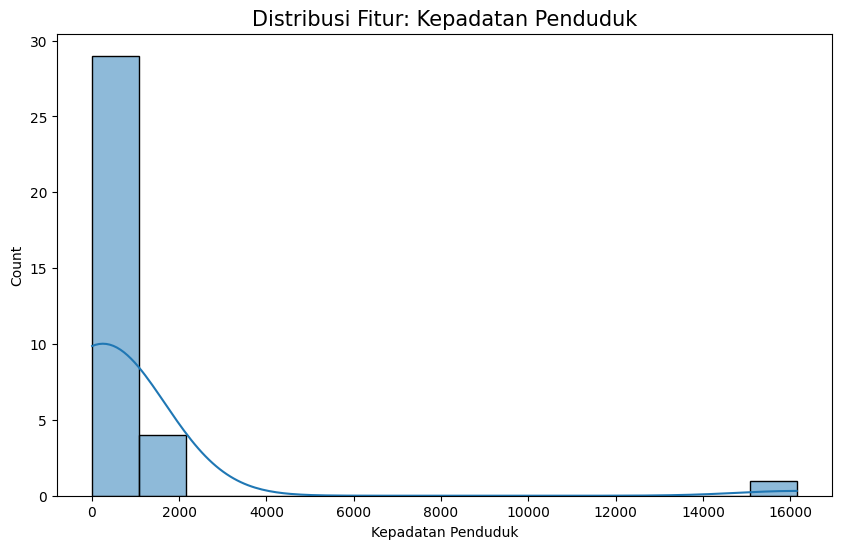


Membuat boxplot untuk deteksi outlier...


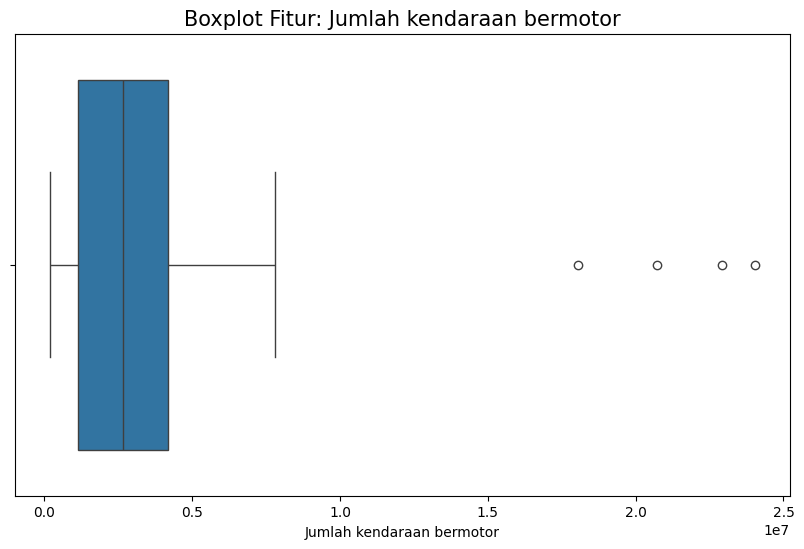

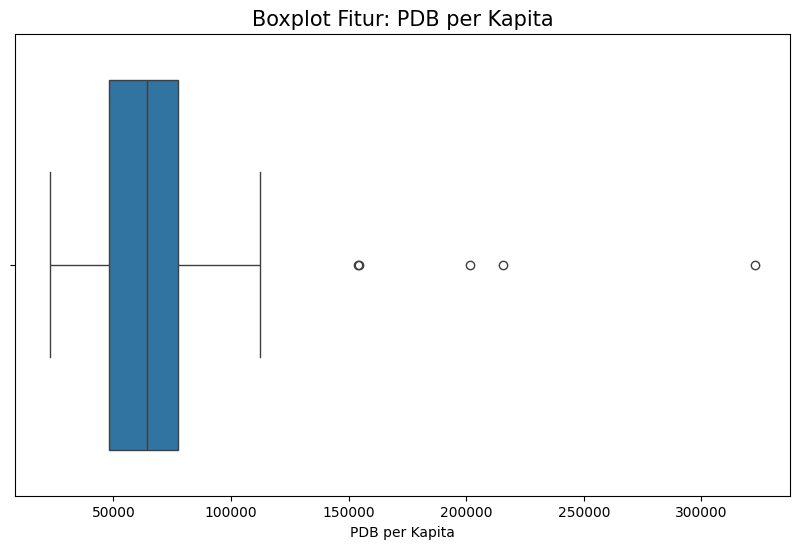

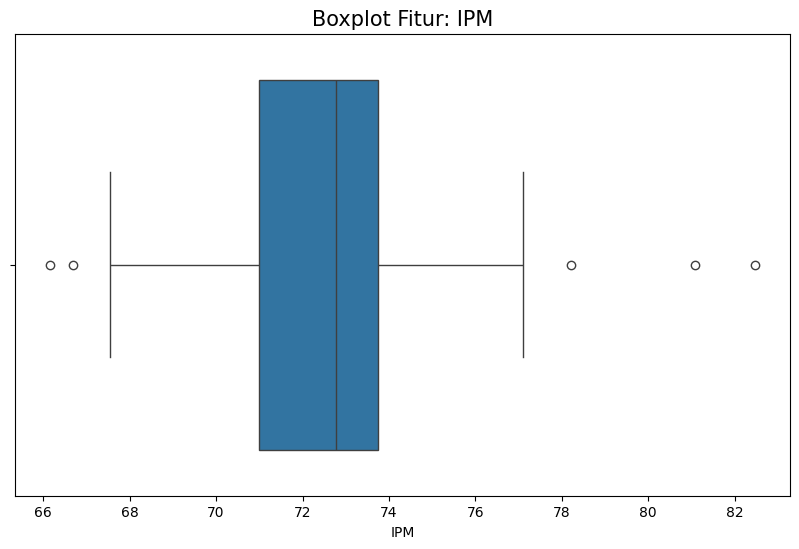

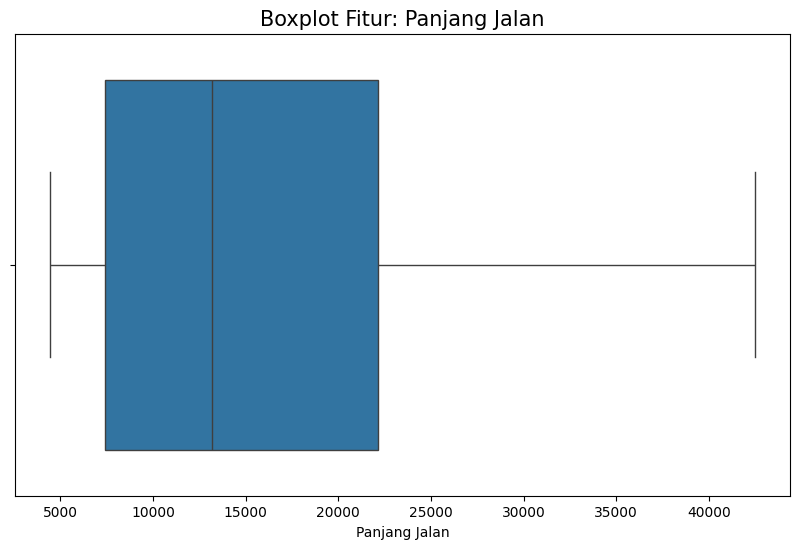

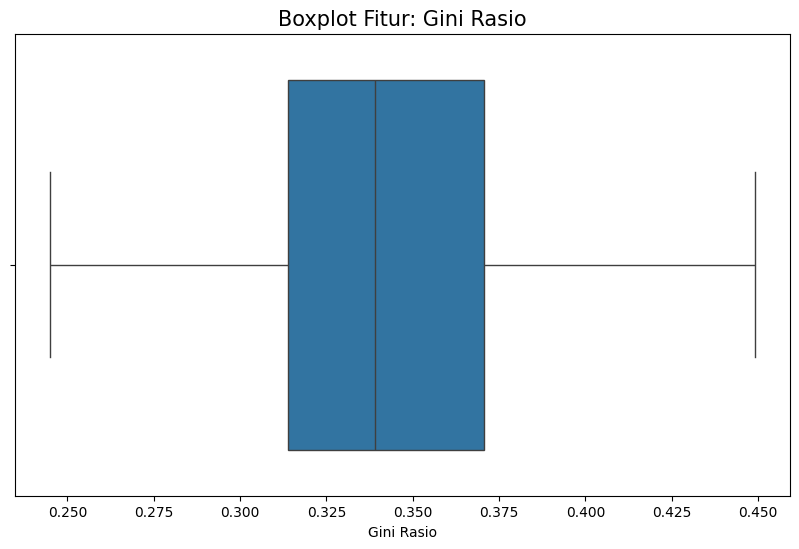

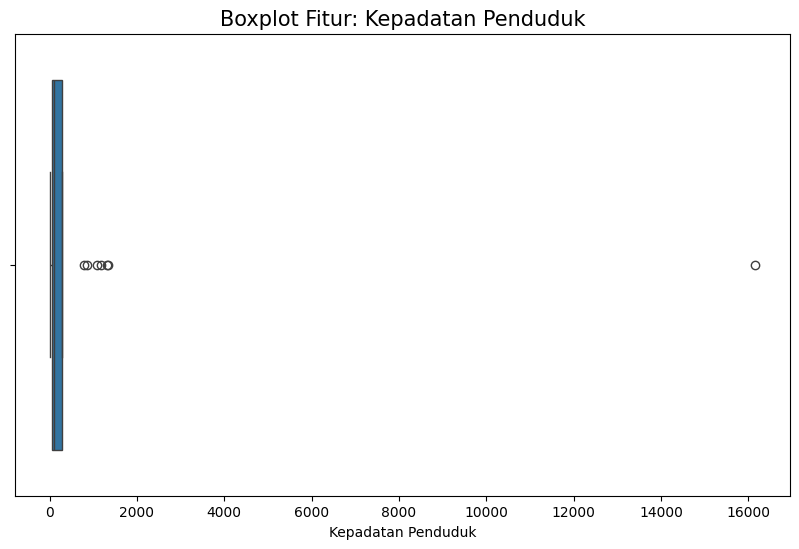


--- 3. Memulai Pre-processing Data ---
Melakukan standarisasi data menggunakan RobustScaler (tahan terhadap outlier)...
Membuat heatmap analisis korelasi...


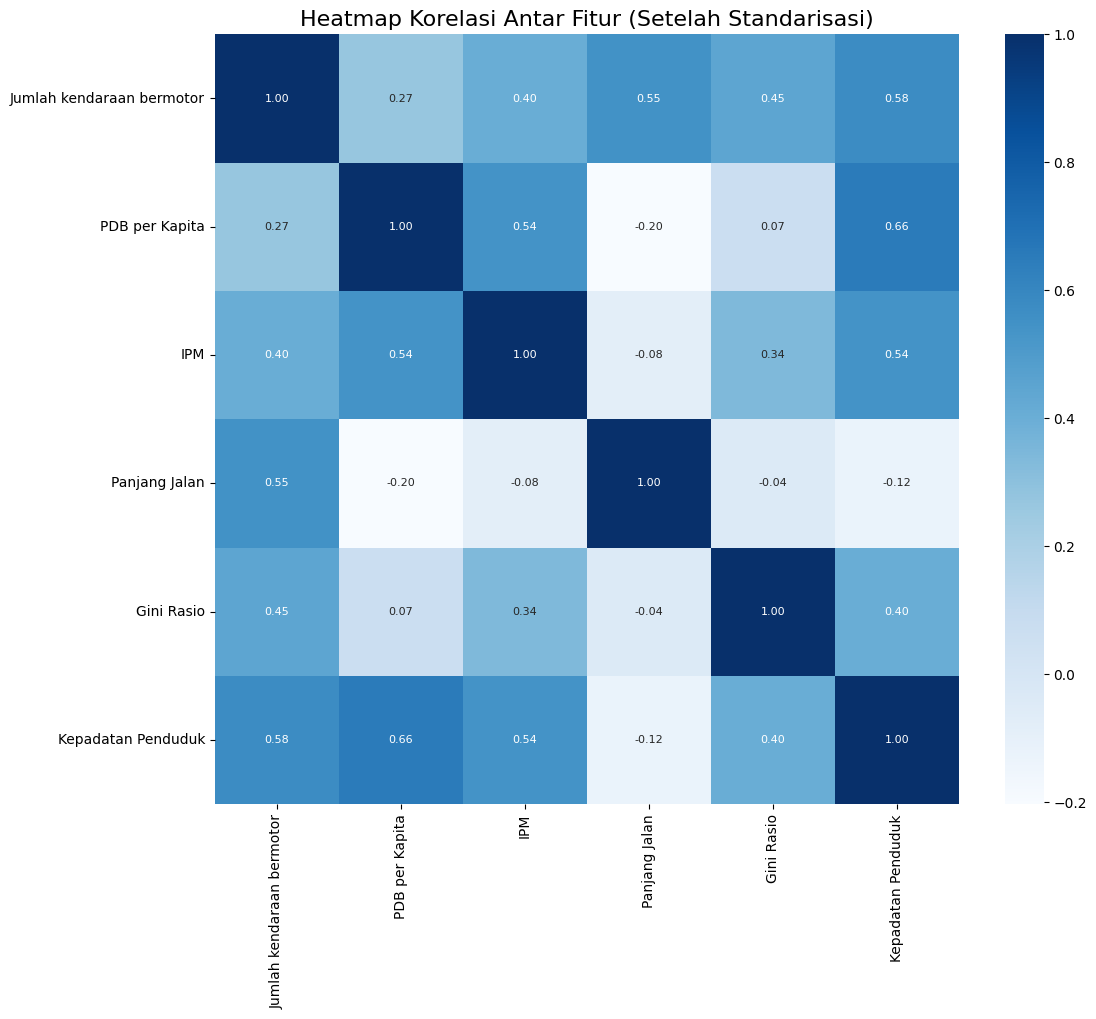


--- 3.5. Memulai Reduksi Dimensi dengan PCA ---


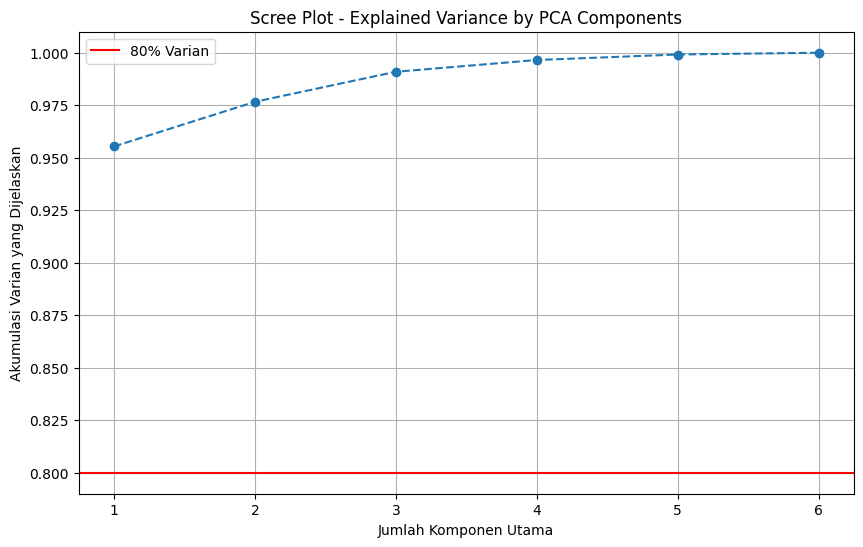

Berdasarkan Scree Plot, kita akan menggunakan 3 komponen utama sesuai referensi.
Data telah berhasil direduksi menjadi 3 dimensi.

--- 4. Memulai Pemodalan & Evaluasi Komparatif (pada data PCA) ---

--- Hasil Evaluasi Model Clustering (pada data PCA) ---
           Silhouette Score  Calinski-Harabasz  Davies-Bouldin
Model                                                         
KMeans_k3          0.622582         496.179046        0.278948
GMM_k3             0.575549         537.497685        0.528961
KMeans_k4          0.535965         533.127463        0.415693
GMM_k4             0.549514         495.246327        0.372438
-------------------------------------------------------

Model terbaik berdasarkan Silhouette Score adalah: KMeans_k3

--- Data Asli dengan Hasil Cluster Terbaik (KMeans_k3) ---
               Provinsi  Cluster
12          JAWA TENGAH        0
14           JAWA TIMUR        0
11           JAWA BARAT        0
10         JAKARTA RAYA        1
0                  ACEH 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')

# --- PENGATURAN AWAL ---
# Menggunakan file data yang baru Anda unggah
FILE_DATA = "C:/Uner/Lomba/Arsen/Data/Data Arsen_L3mao.xlsx"
# Jumlah komponen utama PCA, sesuai referensi
N_COMPONENTS_PCA = 3

print("--- 1. Memulai Analisis Statistika Deskriptif ---")
try:
    df_original = pd.read_excel(FILE_DATA)
except FileNotFoundError:
    print(f"Error: File '{FILE_DATA}' tidak ditemukan.")
    exit()

print("Statistika Deskriptif Data Awal:")
print(df_original.describe())
print("\n")

# Mengidentifikasi kolom entitas (misal: 'Negara', 'Provinsi', 'Wilayah')
# Diasumsikan kolom pertama adalah nama entitasnya
entity_column = df_original.columns[0]
print(f"Kolom entitas yang terdeteksi: '{entity_column}'")


print("\n--- 2. Memulai Exploratory Data Analysis (EDA) ---")
# Secara otomatis memilih semua kolom numerik untuk dianalisis
features = df_original.select_dtypes(include=np.number).columns.tolist()
print(f"Fitur numerik yang akan dianalisis: {features}\n")

print("Membuat visualisasi distribusi untuk setiap fitur...")
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_original[feature], kde=True, bins=15)
    plt.title(f'Distribusi Fitur: {feature}', fontsize=15)
    plt.show()

print("\nMembuat boxplot untuk deteksi outlier...")
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_original[feature])
    plt.title(f'Boxplot Fitur: {feature}', fontsize=15)
    plt.show()


print("\n--- 3. Memulai Pre-processing Data ---")
data_to_cluster = df_original[features]

print("Melakukan standarisasi data menggunakan RobustScaler (tahan terhadap outlier)...")
scaler = RobustScaler()
data_scaled = scaler.fit_transform(data_to_cluster)
data_scaled = pd.DataFrame(data_scaled, columns=features)

print("Membuat heatmap analisis korelasi...")
plt.figure(figsize=(12, 10))
correlation_matrix = data_scaled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", annot_kws={"size": 8})
plt.title('Heatmap Korelasi Antar Fitur (Setelah Standarisasi)', fontsize=16)
plt.show()


print(f"\n--- 3.5. Memulai Reduksi Dimensi dengan PCA ---")
pca = PCA(random_state=42)
pca.fit(data_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(features) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Scree Plot - Explained Variance by PCA Components')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Akumulasi Varian yang Dijelaskan')
plt.grid(True)
plt.axhline(y=0.8, color='r', linestyle='-', label='80% Varian') 
plt.legend()
plt.show()
print(f"Berdasarkan Scree Plot, kita akan menggunakan {N_COMPONENTS_PCA} komponen utama sesuai referensi.")

data_pca = pca.transform(data_scaled)[:, :N_COMPONENTS_PCA]
print(f"Data telah berhasil direduksi menjadi {N_COMPONENTS_PCA} dimensi.\n")


print("--- 4. Memulai Pemodalan & Evaluasi Komparatif (pada data PCA) ---")
k_values = [3, 4] # Menguji k=3 dan k=4
model_results = []
all_labels = {}

for k in k_values:
    # Model KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_labels = kmeans.fit_predict(data_pca)
    model_name_km = f'KMeans_k{k}'
    all_labels[model_name_km] = kmeans_labels
    
    # Model Gaussian Mixture
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm_labels = gmm.fit_predict(data_pca)
    model_name_gmm = f'GMM_k{k}'
    all_labels[model_name_gmm] = gmm_labels

    # Evaluasi kedua model
    for model_name, labels in [(model_name_km, kmeans_labels), (model_name_gmm, gmm_labels)]:
        sil_score = silhouette_score(data_pca, labels)
        calinski_score = calinski_harabasz_score(data_pca, labels)
        davies_score = davies_bouldin_score(data_pca, labels)
        model_results.append({
            "Model": model_name,
            "Silhouette Score": sil_score,        # Makin tinggi makin baik
            "Calinski-Harabasz": calinski_score,  # Makin tinggi makin baik
            "Davies-Bouldin": davies_score        # Makin RENDAH makin baik
        })

evaluation_df = pd.DataFrame(model_results).set_index('Model')
print("\n--- Hasil Evaluasi Model Clustering (pada data PCA) ---")
print(evaluation_df)
print("-" * 55)


# --- 5. HASIL AKHIR ---
# Menentukan model terbaik berdasarkan Silhouette Score tertinggi
best_model_name = evaluation_df['Silhouette Score'].idxmax()
print(f"\nModel terbaik berdasarkan Silhouette Score adalah: {best_model_name}")

# Menambahkan hasil cluster dari model terbaik ke dataframe asli
df_original['Cluster'] = all_labels[best_model_name]
print(f"\n--- Data Asli dengan Hasil Cluster Terbaik ({best_model_name}) ---")
# Menampilkan entitas dan hasil clusternya, diurutkan berdasarkan cluster
print(df_original[[entity_column, 'Cluster']].sort_values('Cluster'))

print("\n--- Analisis Clustering Selesai ---")
print("Langkah selanjutnya adalah analisis spasial menggunakan hasil cluster ini.")

--- 1. Memulai Analisis Statistika Deskriptif ---
Statistika Deskriptif Data Awal:
       Jumlah kendaraan bermotor  PDB per Kapita        IPM  Panjang Jalan  \
count               3.400000e+01       34.000000  34.000000      34.000000   
mean                4.620015e+06    81941.823529  72.906176   15679.470588   
std                 6.505167e+06    61904.718079   3.426929   10402.934447   
min                 1.924350e+05    23078.000000  66.160000    4449.000000   
25%                 1.135204e+06    48233.250000  71.000000    7403.250000   
50%                 2.666402e+06    64109.500000  72.785000   13209.500000   
75%                 4.188368e+06    77359.000000  73.747500   22143.250000   
max                 2.402367e+07   322619.000000  82.460000   42466.000000   

       Gini Rasio  Kepadatan Penduduk  
count   34.000000           34.000000  
mean     0.344324          752.647059  
std      0.046847         2749.123165  
min      0.245000           10.000000  
25%      0.314

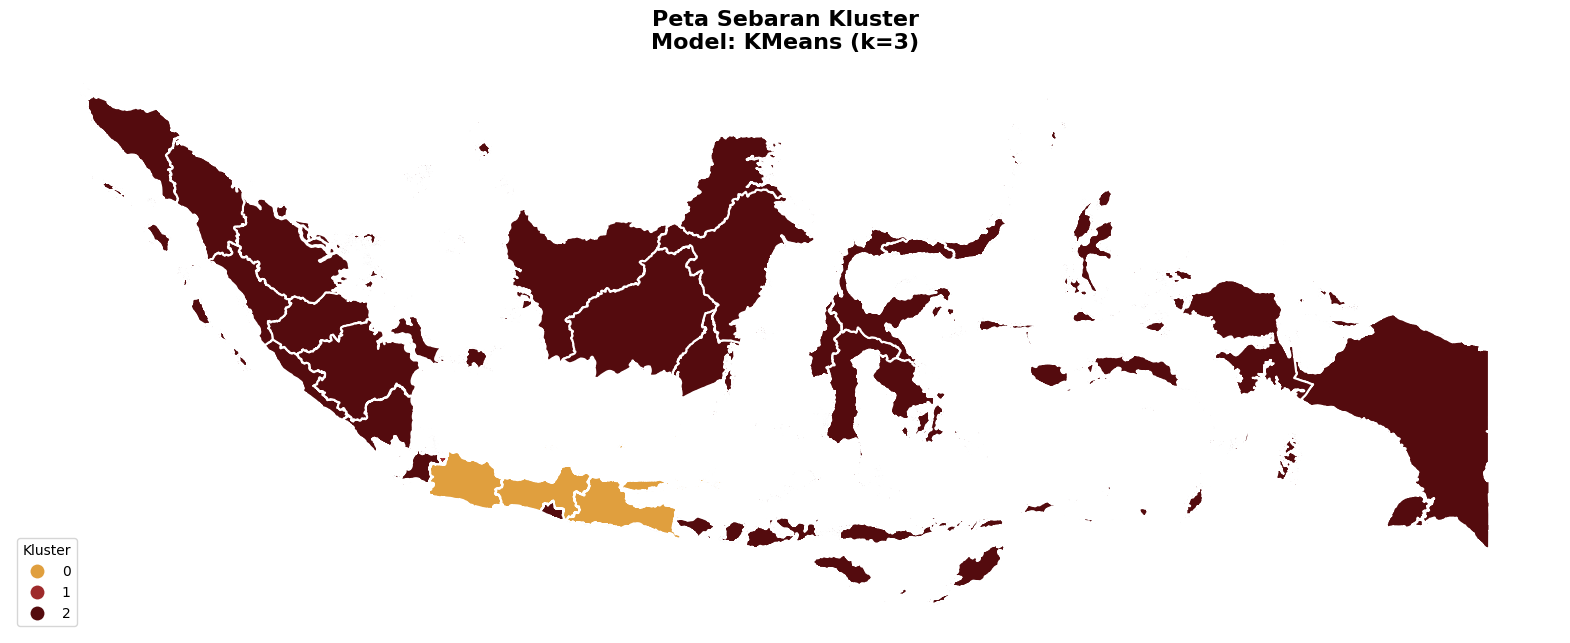


Menampilkan peta untuk model: GMM (k=3)...


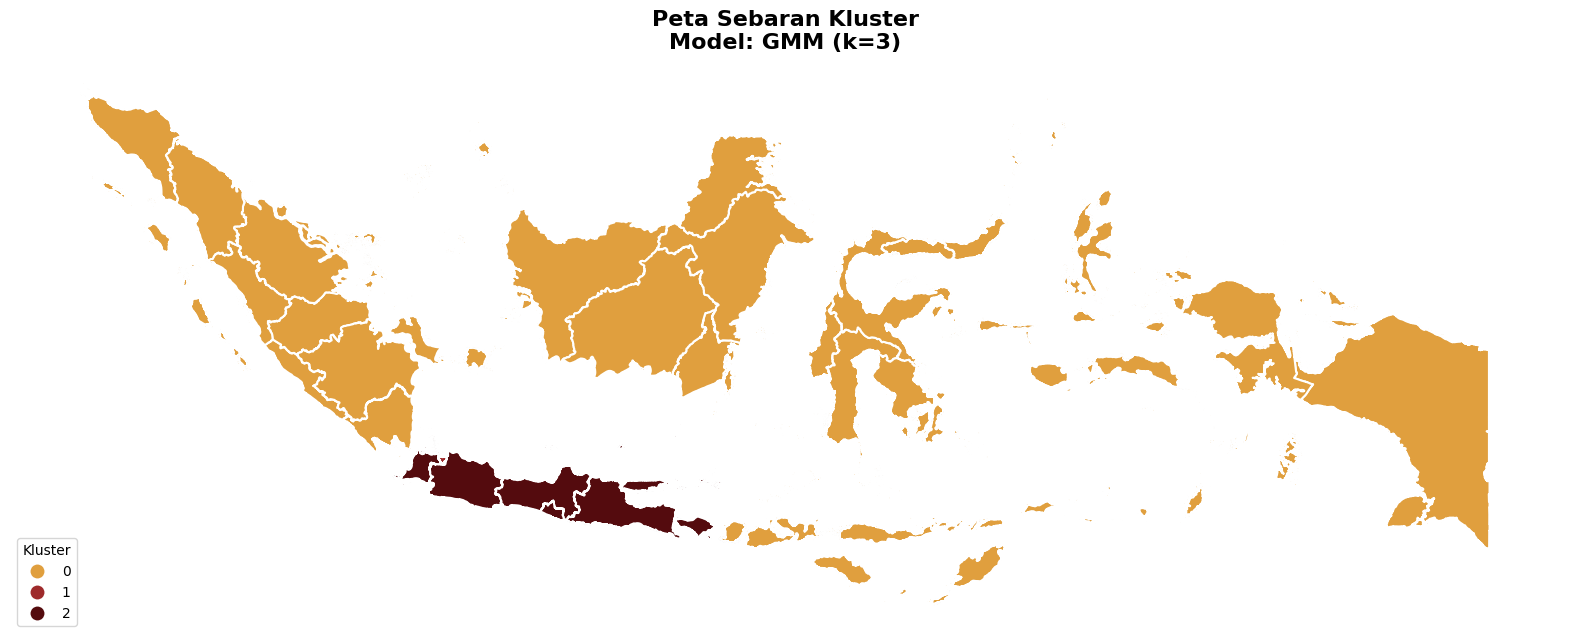


Menampilkan peta untuk model: KMeans (k=4)...


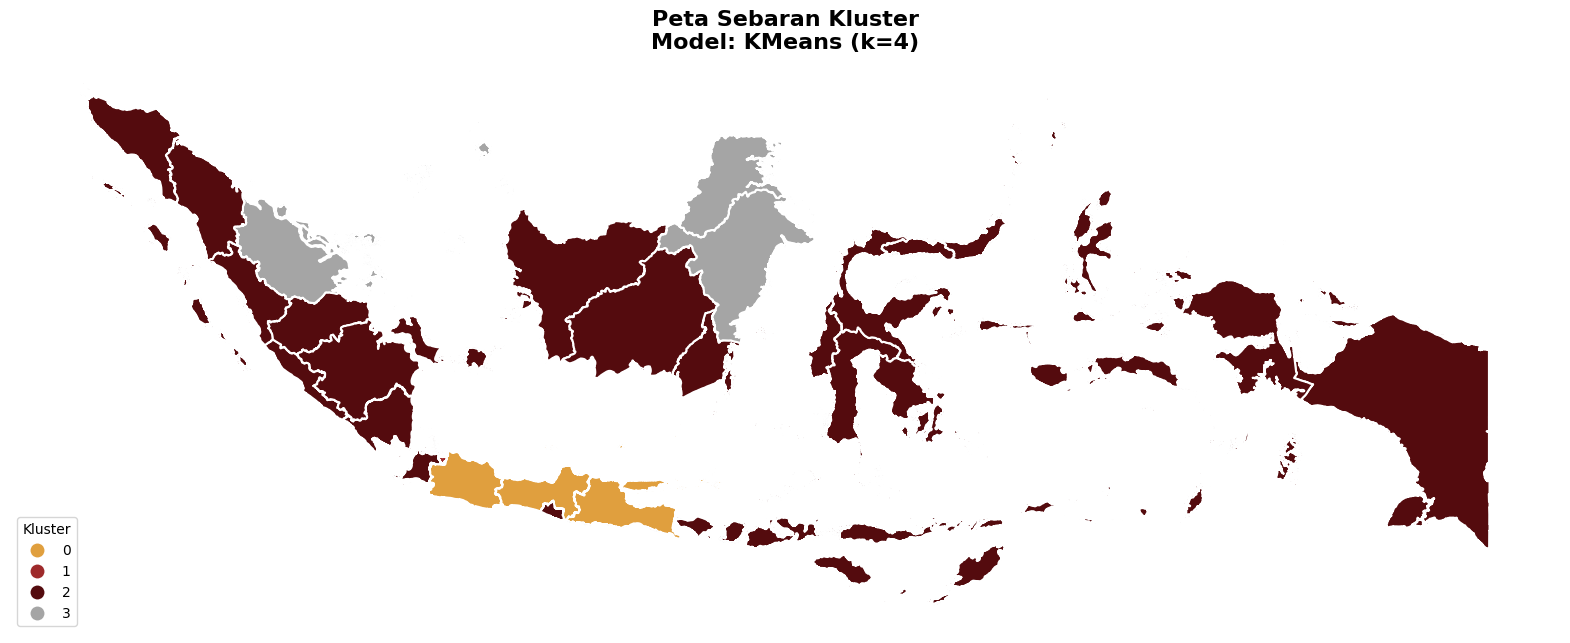


Menampilkan peta untuk model: GMM (k=4)...


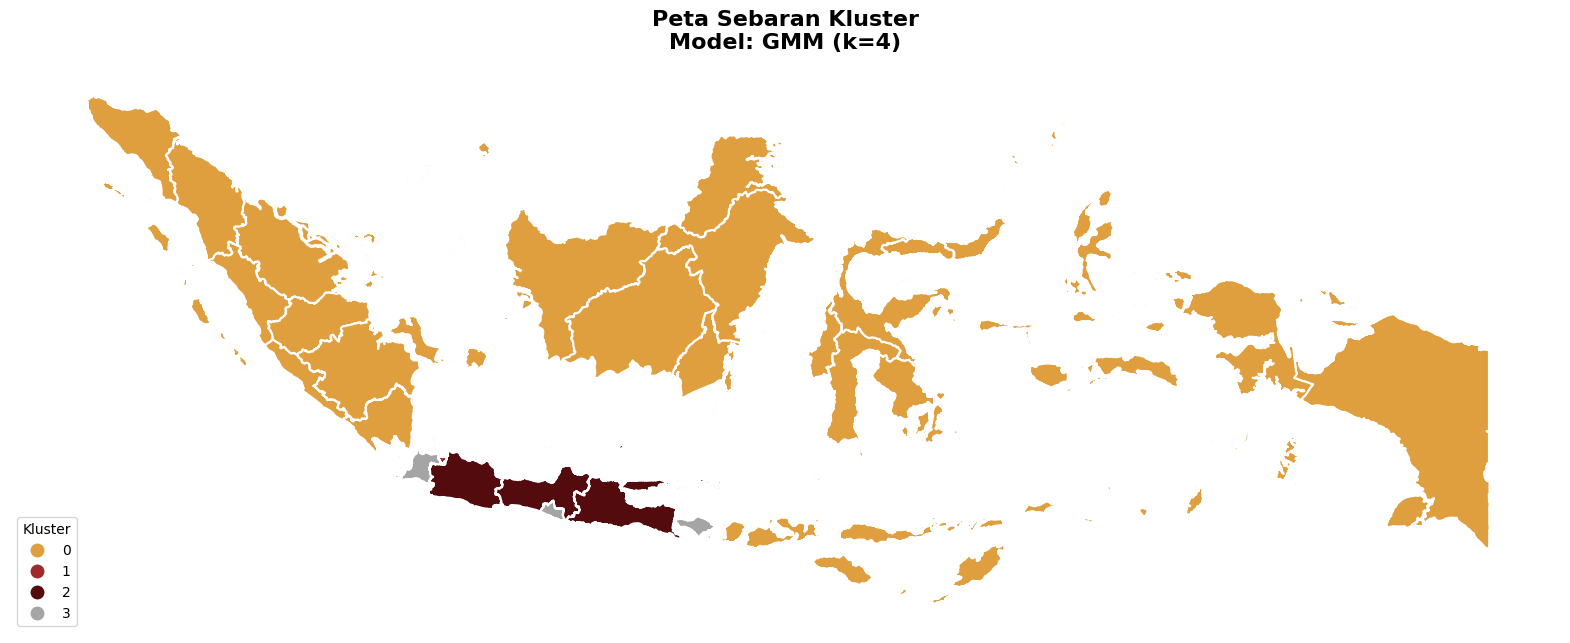


--- Analisis Selesai ---


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import geopandas as gpd
from matplotlib.colors import ListedColormap
import warnings

warnings.filterwarnings('ignore')

# --- PENGATURAN AWAL ---
FILE_DATA = "C:/Uner/Lomba/Arsen/Data/Data Arsen_L3mao.xlsx"
FILE_SHP = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp" 
KOLOM_WILAYAH_PETA = 'NAME_1'
N_COMPONENTS_PCA = 3
CUSTOM_COLORS = ['#E09F3E', '#9E2A2B', '#540B0E', '#A5A5A5'] 
BORDER_COLOR = 'white' 
BORDER_LINEWIDTH = 1.5

print("--- 1. Memulai Analisis Statistika Deskriptif ---")
try:
    df_original = pd.read_excel(FILE_DATA)
except FileNotFoundError:
    print(f"Error: File '{FILE_DATA}' tidak ditemukan.")
    exit()
except Exception as e:
    print(f"Error saat membaca file: {e}")
    exit()

print("Statistika Deskriptif Data Awal:")
print(df_original.describe())

entity_column = df_original.columns[0]
print(f"\nKolom entitas yang terdeteksi: '{entity_column}'")


# --- 2, 3, 4. EDA, PRE-PROCESSING, CLUSTERING ---
print("\n--- 2, 3, 4. Memulai EDA, Pre-processing, dan Clustering ---")
features = df_original.select_dtypes(include=np.number).columns.tolist()
data_to_cluster = df_original[features]
scaler = RobustScaler()
data_scaled = scaler.fit_transform(data_to_cluster)
data_scaled = pd.DataFrame(data_scaled, columns=features)
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=42)
data_pca = pca.fit_transform(data_scaled)

k_values = [3, 4]
model_results = []
all_labels = {}
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    all_labels[f'KMeans_k{k}'] = kmeans.fit_predict(data_pca)
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    all_labels[f'GMM_k{k}'] = gmm.fit_predict(data_pca)

for model_name, labels in all_labels.items():
    model_results.append({
        "Model": model_name,
        "Silhouette Score": silhouette_score(data_pca, labels),
        "Calinski-Harabasz": calinski_harabasz_score(data_pca, labels),
        "Davies-Bouldin": davies_bouldin_score(data_pca, labels)
    })

evaluation_df = pd.DataFrame(model_results).set_index('Model')
print("\n--- Hasil Evaluasi Model Clustering ---")
print(evaluation_df)
print("-" * 55)


# --- 5. HASIL AKHIR ---
# Menyiapkan dataframe dengan semua hasil cluster
df_results = df_original.copy()
for model_name, labels in all_labels.items():
    df_results[model_name] = labels

# <<< PERUBAHAN UTAMA DI SINI >>>
print("\n--- Rincian Profil dan Anggota Cluster per Model ---")
for model_name in all_labels.keys():
    print(f"\n==============================================")
    print(f"--- Model: {model_name} ---")
    print(f"==============================================")
    
    # Kelompokkan data berdasarkan hasil cluster dari model saat ini
    grouped = df_results.groupby(model_name)
    
    # Iterasi melalui setiap cluster yang terbentuk
    for cluster_id, group_df in grouped:
        count = len(group_df)
        provinces = group_df[entity_column].tolist()
        
        # Menghitung nilai rata-rata (centroid) dari semua fitur asli
        centroid_values = group_df[features].mean()

        print(f"\n[ Kluster {cluster_id} ] - Jumlah Anggota: {count}")
        print("  Profil Rata-Rata Variabel:")
        # Menampilkan setiap fitur dan nilai rata-ratanya
        for feature_name, value in centroid_values.items():
            print(f"    - {feature_name}: {value:,.2f}")

        print("  Anggota Kluster:")
        # Menampilkan daftar anggota
        for province in provinces:
            print(f"    - {province}")
# <<< AKHIR DARI PERUBAHAN >>>


# --- 6. VISUALISASI PETA UNTUK SETIAP MODEL ---
# (Bagian ini tidak diubah)
print("\n--- 6. Memulai Visualisasi Peta untuk Setiap Model ---")
try:
    gdf = gpd.read_file(FILE_SHP)
    print("Shapefile berhasil dimuat.")
except Exception as e:
    print(f"Error membaca Shapefile: {e}")
    print("Pastikan path di variabel 'FILE_SHP' sudah benar.")
    exit()

gdf[KOLOM_WILAYAH_PETA] = gdf[KOLOM_WILAYAH_PETA].str.upper().str.strip()
df_results[entity_column] = df_results[entity_column].str.upper().str.strip()
merged_gdf = gdf.merge(df_results, left_on=KOLOM_WILAYAH_PETA, right_on=entity_column, how='left')

for model_name in all_labels.keys():
    k = int(model_name.split('_k')[-1])
    custom_cmap = ListedColormap(CUSTOM_COLORS[:k])
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 15)) 
    merged_gdf.plot(column=model_name, ax=ax, legend=True, categorical=True,
                    legend_kwds={'title': "Kluster", 'loc': 'lower left'},
                    cmap=custom_cmap, edgecolor=BORDER_COLOR, linewidth=BORDER_LINEWIDTH, 
                    missing_kwds={"color": "lightgrey", "label": "Data Hilang/Tidak Cocok"})

    model_display_name = model_name.replace('_k', ' (k=') + ')'
    ax.set_title(f'Peta Sebaran Kluster\nModel: {model_display_name}', fontsize=16, fontweight='bold')
    ax.set_axis_off()
    
    print(f"\nMenampilkan peta untuk model: {model_display_name}...")
    plt.show()

print("\n--- Analisis Selesai ---")

# Analisis Spasial

In [7]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Import library untuk analisis spasial dari PySAL
import libpysal as lps
from esda.moran import Moran, Moran_Local
from splot.esda import plot_moran
from spreg import OLS, ML_Lag, ML_Error
# PERHATIKAN: Impor untuk diagnostik yang error sudah dihapus

# --- 0. PENGATURAN AWAL ---
FILE_DATA = "C:/Uner/Lomba/Arsen/Data/Data Arsen_L3mao.xlsx"
FILE_SHP = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp" 
KOLOM_WILAYAH_PETA = 'NAME_1'

print("--- 1. Memuat Data ---")
try:
    df = pd.read_excel(FILE_DATA)
    gdf_orig = gpd.read_file(FILE_SHP)
except Exception as e:
    print(f"Error memuat file: {e}")
    exit()

# Mengidentifikasi kolom dan variabel
entity_column = df.columns[0]
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
Y_VARIABLE_ORIGINAL = numeric_features[0]
X_VARIABLES = [var for var in numeric_features if var != Y_VARIABLE_ORIGINAL]

print(f"Variabel Dependen (Y) dipilih: '{Y_VARIABLE_ORIGINAL}'")
print(f"Variabel Independen (X) dipilih: {X_VARIABLES}\n")

# Menggabungkan data
gdf_orig[KOLOM_WILAYAH_PETA] = gdf_orig[KOLOM_WILAYAH_PETA].str.upper().str.strip()
df[entity_column] = df[entity_column].str.upper().str.strip()
gdf = gdf_orig.merge(df, left_on=KOLOM_WILAYAH_PETA, right_on=entity_column, how='inner')
gdf.dropna(subset=[Y_VARIABLE_ORIGINAL] + X_VARIABLES, inplace=True)
print(f"Data berhasil digabungkan. Jumlah wilayah: {len(gdf)}\n")

# Melakukan transformasi log
gdf['log_Y'] = np.log(gdf[Y_VARIABLE_ORIGINAL])
Y_VARIABLE_TRANSFORMED = 'log_Y'

# Membuat Matriks Pembobot Spasial
wq = lps.weights.Queen.from_dataframe(gdf)
wq.transform = 'r'

# --- PEMODELAN REGRESI SPASIAL ---
print("--- Memulai Pemodelan Regresi Spasial ---")
y = np.array(gdf[Y_VARIABLE_TRANSFORMED]).reshape(len(gdf), 1)
X = sm.add_constant(np.array(gdf[X_VARIABLES]))
x_names = ['CONST'] + [var.replace(' ', '_') for var in X_VARIABLES]

print("\n--- Model 1: Ordinary Least Squares (OLS) ---")
ols = OLS(y, X, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ols.summary)

# --- BAGIAN UJI DIAGNOSTIK LM SUDAH DIHAPUS ---

print("\n--- Model 2: Spatial Lag Model (ML_Lag) ---")
ml_lag = ML_Lag(y, X, w=wq, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ml_lag.summary)

print("\n--- Model 3: Spatial Error Model (ML_Error) ---")
ml_err = ML_Error(y, X, w=wq, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ml_err.summary)

print("\n--- Analisis Spasial Selesai ---")
print("==============================================================================")
print("PANDUAN PEMILIHAN MODEL:")
print("Bandingkan ringkasan ketiga model di atas (OLS, ML_Lag, ML_Error).")
print("Model terbaik biasanya memiliki:")
print("1. Nilai Log-likelihood PALING TINGGI.")
print("2. Nilai AIC PALING RENDAH.")
print("3. Nilai R-squared PALING TINGGI.")
print("==============================================================================")

--- 1. Memuat Data ---
Variabel Dependen (Y) dipilih: 'Jumlah kendaraan bermotor'
Variabel Independen (X) dipilih: ['PDB per Kapita', 'IPM', 'Panjang Jalan', 'Gini Rasio', 'Kepadatan Penduduk']

Data berhasil digabungkan. Jumlah wilayah: 34

('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 21, ' is an island (no neighbors)')
--- Memulai Pemodelan Regresi Spasial ---

--- Model 1: Ordinary Least Squares (OLS) ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :       log_Y                Number of Observations:          34
Mean dependent var  :     14.6272                Number of Variables   :           6
S.D. dependent var  :      1.2192                Degrees of Freedom    :          28
R-squared           :    

# Analisis Spasial Lanjutan

--- 1. Memuat Data ---
Kolom Wilayah terdeteksi: 'Provinsi'
Variabel Dependen (Y) dipilih: 'Jumlah kendaraan bermotor'
Variabel Independen (X) dipilih: ['PDB per Kapita', 'IPM', 'Panjang Jalan', 'Gini Rasio', 'Kepadatan Penduduk']

Data berhasil digabungkan. Jumlah wilayah: 34

--- Pengecekan Multikolinearitas dengan VIF ---
              feature        VIF
0      PDB per Kapita   6.124719
1                 IPM  97.001227
2       Panjang Jalan   3.493589
3          Gini Rasio  79.078161
4  Kepadatan Penduduk   2.241465

Peringatan: Terdeteksi multikolinearitas tinggi (VIF > 10).

--- Membuat Matriks Pembobot Spasial ---
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 21, ' is an island (no neighbors)')
Matriks pembobot 'Queen Contiguity' berhasil dibuat.

--- Uji Autokorelasi Spasial Global (Moran's I) untuk 'log_Y' ---
Moran's I: 0.6277
P-value: 0.0010
 -> Hasilnya signifi

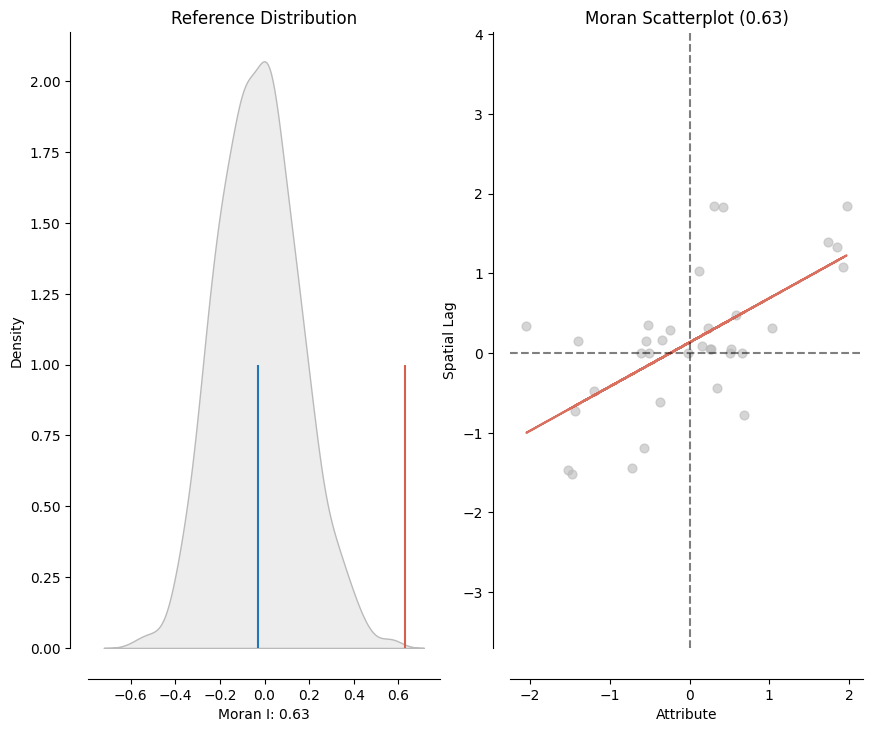


--- Analisis Hotspot & Coldspot (LISA) untuk 'log_Y' ---


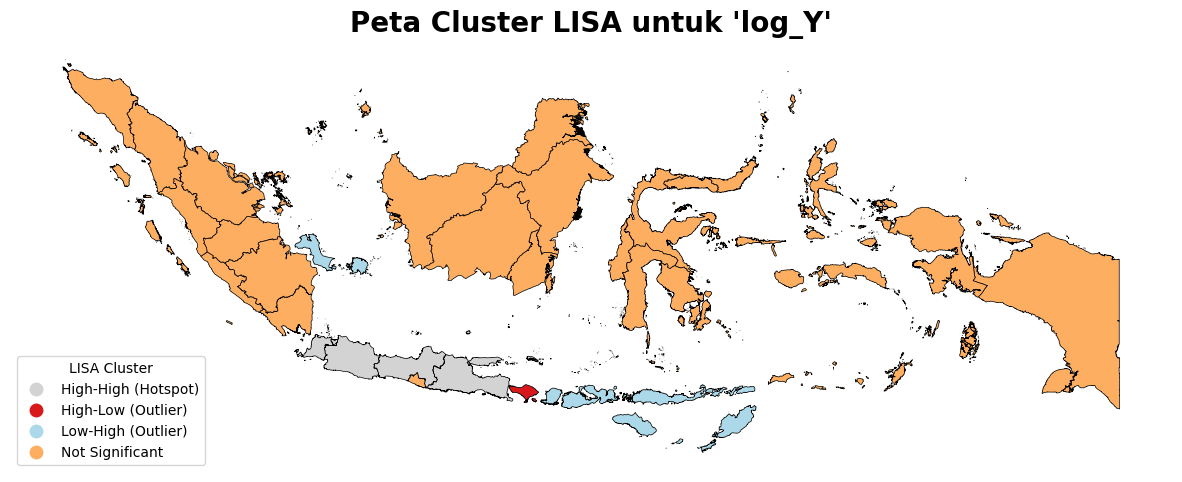

Peta Cluster LISA telah ditampilkan.

--- Memulai Pemodelan Regresi Spasial ---

--- Model 1: Ordinary Least Squares (OLS) ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :       log_Y                Number of Observations:          34
Mean dependent var  :     14.6272                Number of Variables   :           6
S.D. dependent var  :      1.2192                Degrees of Freedom    :          28
R-squared           :      0.8232
Adjusted R-squared  :      0.7916
Sum squared residual:      8.6724                F-statistic           :     26.0766
Sigma-square        :       0.310                Prob(F-statistic)     :   9.954e-10
S.E. of regression  :       0.557                Log likelihood        :     -25.018
Sigma-square ML     :       0.255                Akaike info criterion :      62.037
S.E of regression M

In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Import library untuk analisis spasial dari PySAL
import libpysal as lps
from esda.moran import Moran, Moran_Local
from splot.esda import plot_moran
from spreg import OLS, ML_Lag, ML_Error
import warnings

warnings.filterwarnings('ignore')

# --- 0. PENGATURAN AWAL ---
FILE_DATA = "C:/Uner/Lomba/Arsen/Data/Data Arsen_L3mao.xlsx"
# !! PENTING: GANTI DENGAN PATH FILE SHAPEFILE (.shp) ANDA !!
FILE_SHP = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp" 
# !! PENTING: GANTI DENGAN NAMA KOLOM DI FILE PETA YANG BERISI NAMA WILAYAH !!
KOLOM_WILAYAH_PETA = 'NAME_1'


print("--- 1. Memuat Data ---")
try:
    df = pd.read_excel(FILE_DATA)
    gdf_orig = gpd.read_file(FILE_SHP)
except Exception as e:
    print(f"Error memuat file: {e}")
    exit()

# Mengidentifikasi kolom wilayah dan fitur numerik secara otomatis
entity_column = df.columns[0]
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

# --- PENGATURAN VARIABEL (BISA ANDA UBAH) ---
# Secara otomatis memilih variabel Y dan X. Silakan ganti jika perlu.
Y_VARIABLE_ORIGINAL = numeric_features[0]
X_VARIABLES = numeric_features[1:] # Menggunakan semua sisa variabel numerik

print(f"Kolom Wilayah terdeteksi: '{entity_column}'")
print(f"Variabel Dependen (Y) dipilih: '{Y_VARIABLE_ORIGINAL}'")
print(f"Variabel Independen (X) dipilih: {X_VARIABLES}\n")


# Menggabungkan data spasial dengan data atribut
gdf_orig[KOLOM_WILAYAH_PETA] = gdf_orig[KOLOM_WILAYAH_PETA].str.upper().str.strip()
df[entity_column] = df[entity_column].str.upper().str.strip()
gdf = gdf_orig.merge(df, left_on=KOLOM_WILAYAH_PETA, right_on=entity_column, how='inner')
gdf.dropna(subset=[Y_VARIABLE_ORIGINAL] + X_VARIABLES, inplace=True)
print(f"Data berhasil digabungkan. Jumlah wilayah: {len(gdf)}\n")

# Melakukan transformasi log (jika diperlukan)
gdf['log_Y'] = np.log(gdf[Y_VARIABLE_ORIGINAL])
Y_VARIABLE_TRANSFORMED = 'log_Y'

# Pengecekan Multikolinearitas dengan VIF
print("--- Pengecekan Multikolinearitas dengan VIF ---")
X_for_vif = gdf[X_VARIABLES].copy()
vif_data = pd.DataFrame()
vif_data["feature"] = X_VARIABLES
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(len(X_VARIABLES))]
print(vif_data)
if (vif_data['VIF'] > 10).any():
    print("\nPeringatan: Terdeteksi multikolinearitas tinggi (VIF > 10).\n")

# Membuat Matriks Pembobot Spasial
print("--- Membuat Matriks Pembobot Spasial ---")
wq = lps.weights.Queen.from_dataframe(gdf)
wq.transform = 'r'
print("Matriks pembobot 'Queen Contiguity' berhasil dibuat.\n")

print(f"--- Uji Autokorelasi Spasial Global (Moran's I) untuk '{Y_VARIABLE_TRANSFORMED}' ---")
moran = Moran(gdf[Y_VARIABLE_TRANSFORMED], wq)
print(f"Moran's I: {moran.I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")
if moran.p_sim < 0.05: print(" -> Hasilnya signifikan! Ada bukti pengelompokan spasial.")
else: print(" -> Hasilnya tidak signifikan. Pola spasial kemungkinan acak.")
plot_moran(moran, figsize=(10, 8))
plt.show()

print(f"\n--- Analisis Hotspot & Coldspot (LISA) untuk '{Y_VARIABLE_TRANSFORMED}' ---")
lisa = Moran_Local(gdf[Y_VARIABLE_TRANSFORMED], wq)
labels = ['Not Significant', 'High-High (Hotspot)', 'Low-Low (Coldspot)', 'Low-High (Outlier)', 'High-Low (Outlier)']
gdf['lisa_label'] = pd.Series(lisa.q, index=gdf.index).map({1: labels[1], 2: labels[2], 3: labels[3], 4: labels[4]})
gdf.loc[lisa.p_sim >= 0.05, 'lisa_label'] = labels[0]
colors = ['lightgrey', '#d7191c', '#2c7bb6', '#abd9e9', '#fdae61']

fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(column='lisa_label', categorical=True, cmap=ListedColormap(colors), linewidth=0.5, ax=ax, edgecolor='black', legend=True, legend_kwds={'title': "LISA Cluster", 'loc': 'lower left'})
ax.set_title(f"Peta Cluster LISA untuk '{Y_VARIABLE_TRANSFORMED}'", fontsize=20, fontweight='bold')
ax.set_axis_off()
plt.show()
print("Peta Cluster LISA telah ditampilkan.\n")

print("--- Memulai Pemodelan Regresi Spasial ---")
y = np.array(gdf[Y_VARIABLE_TRANSFORMED]).reshape(len(gdf), 1)
X = sm.add_constant(np.array(gdf[X_VARIABLES]))
x_names = ['CONST'] + [var.replace(' ', '_') for var in X_VARIABLES]

print("\n--- Model 1: Ordinary Least Squares (OLS) ---")
ols = OLS(y, X, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ols.summary)

print("\n--- Uji Diagnostik & Pemilihan Model ---")
print("Karena sering terjadi error 'ImportError' akibat versi library, bagian diagnostik otomatis (LM Test) akan dilewati.")
print("Sebagai gantinya, kita akan langsung membandingkan ketiga model berdasarkan metrik evaluasi.")

print("\n--- Model 2: Spatial Lag Model (ML_Lag) ---")
ml_lag = ML_Lag(y, X, w=wq, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ml_lag.summary)

print("\n--- Model 3: Spatial Error Model (ML_Error) ---")
ml_err = ML_Error(y, X, w=wq, name_y=Y_VARIABLE_TRANSFORMED, name_x=x_names)
print(ml_err.summary)

print("\n--- Analisis Spasial Selesai ---")
print("==============================================================================")
print("PANDUAN PEMILIHAN MODEL:")
print("Bandingkan ringkasan ketiga model di atas (OLS, ML_Lag, ML_Error).")
print("Model terbaik biasanya memiliki:")
print("1. Nilai Log-likelihood PALING TINGGI.")
print("2. Nilai AIC PALING RENDAH.")
print("3. Nilai R-squared PALING TINGGI.")
print("==============================================================================")

# Peta Kombinasi dengan Bubble Plot

--- 1, 2, 3. Memuat, Memproses, dan Melakukan Clustering Data ---
Pemodelan clustering selesai.

--- 4. Memulai Visualisasi Bubble Map ---
Shapefile berhasil dimuat.
Variabel yang digunakan untuk ukuran bubble: 'IPM'

Menampilkan peta untuk model: KMeans (k=3)...


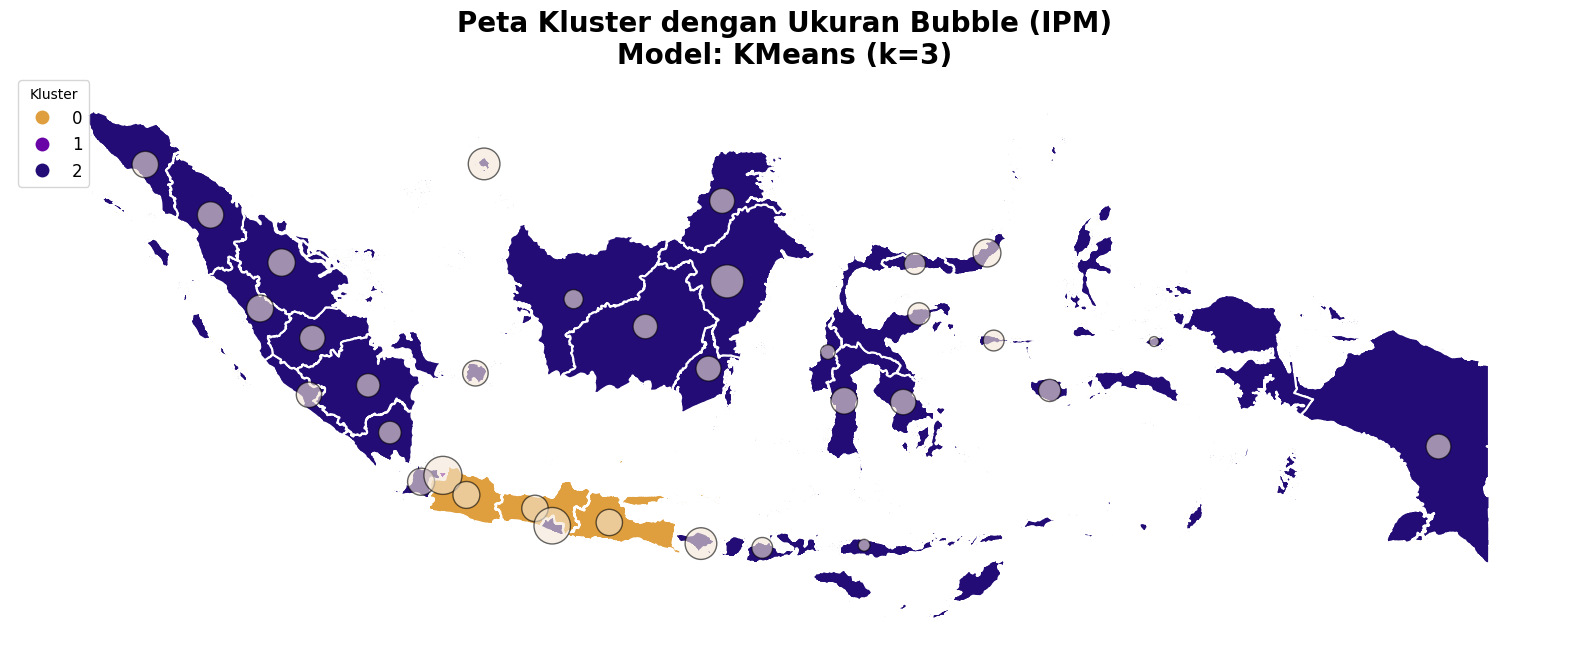


Menampilkan peta untuk model: GMM (k=3)...


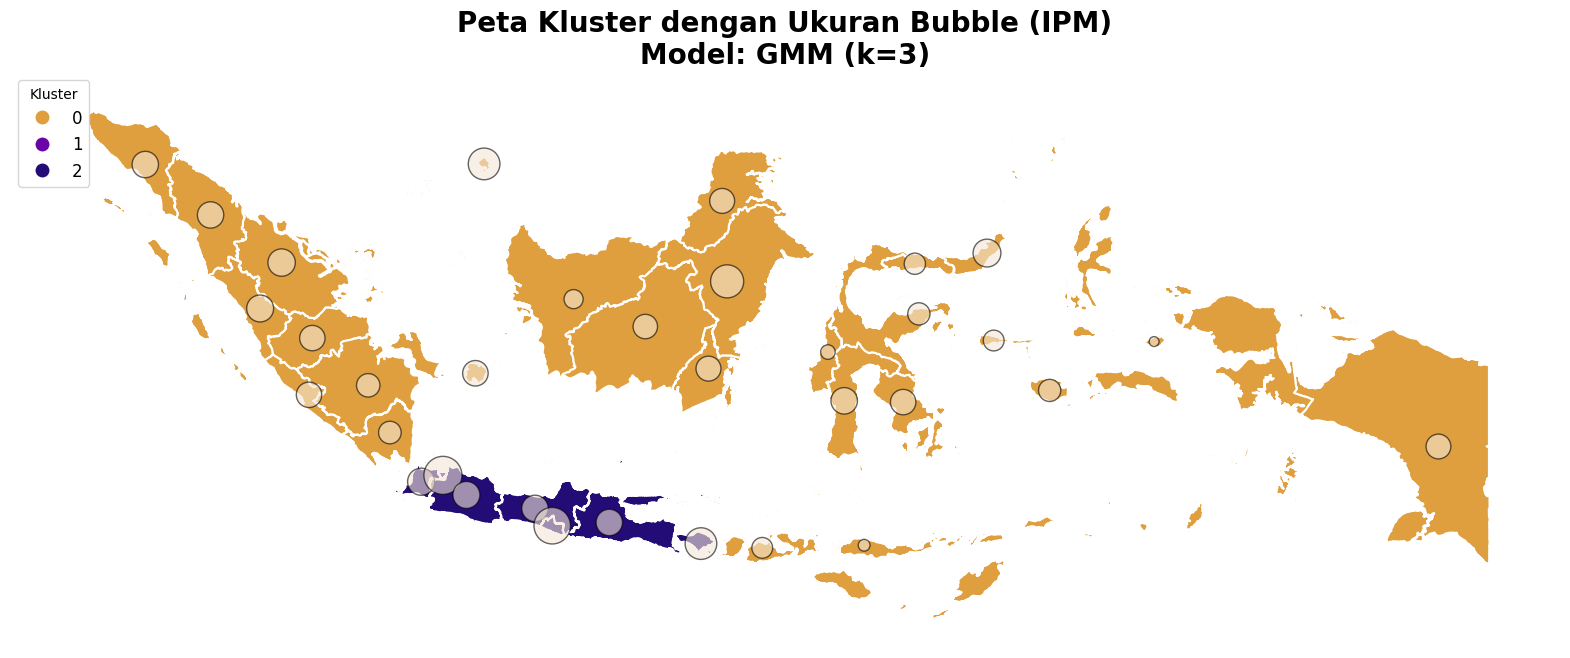


Menampilkan peta untuk model: KMeans (k=4)...


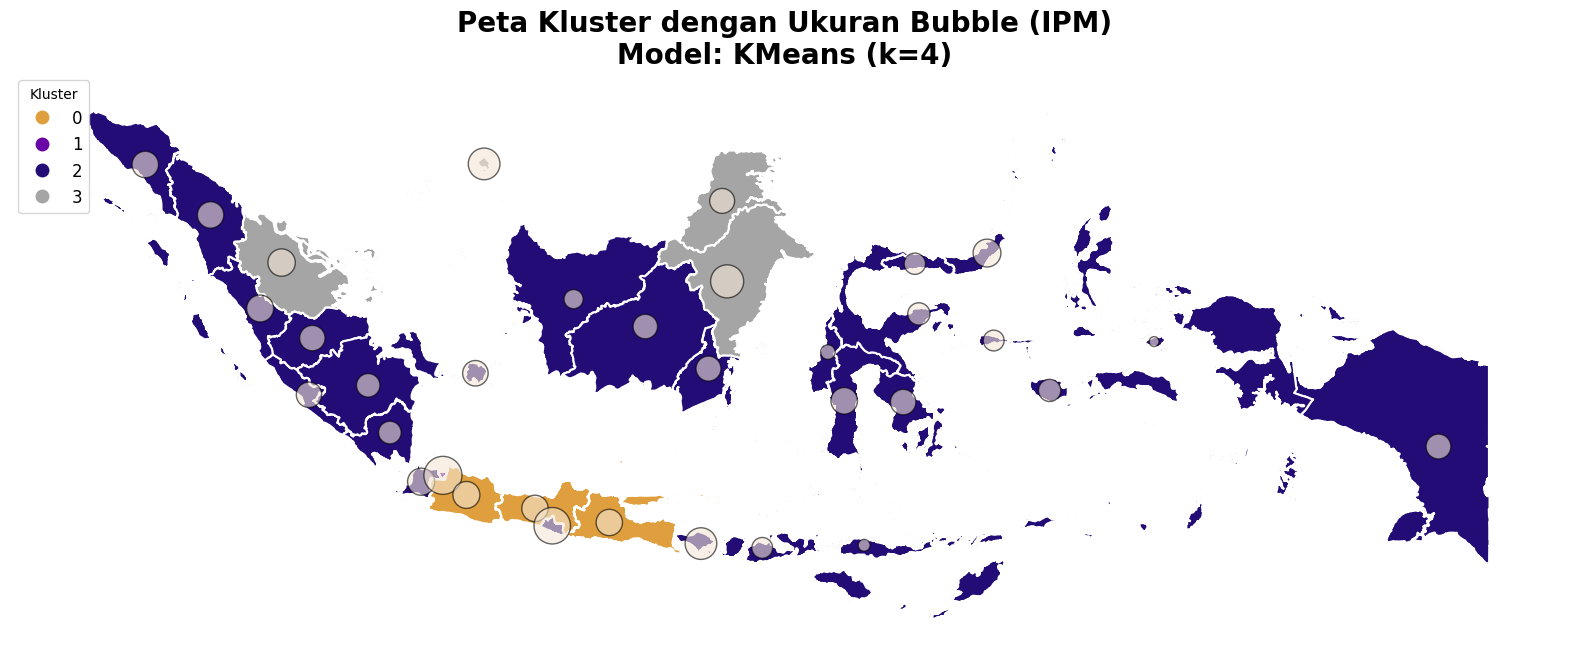


Menampilkan peta untuk model: GMM (k=4)...


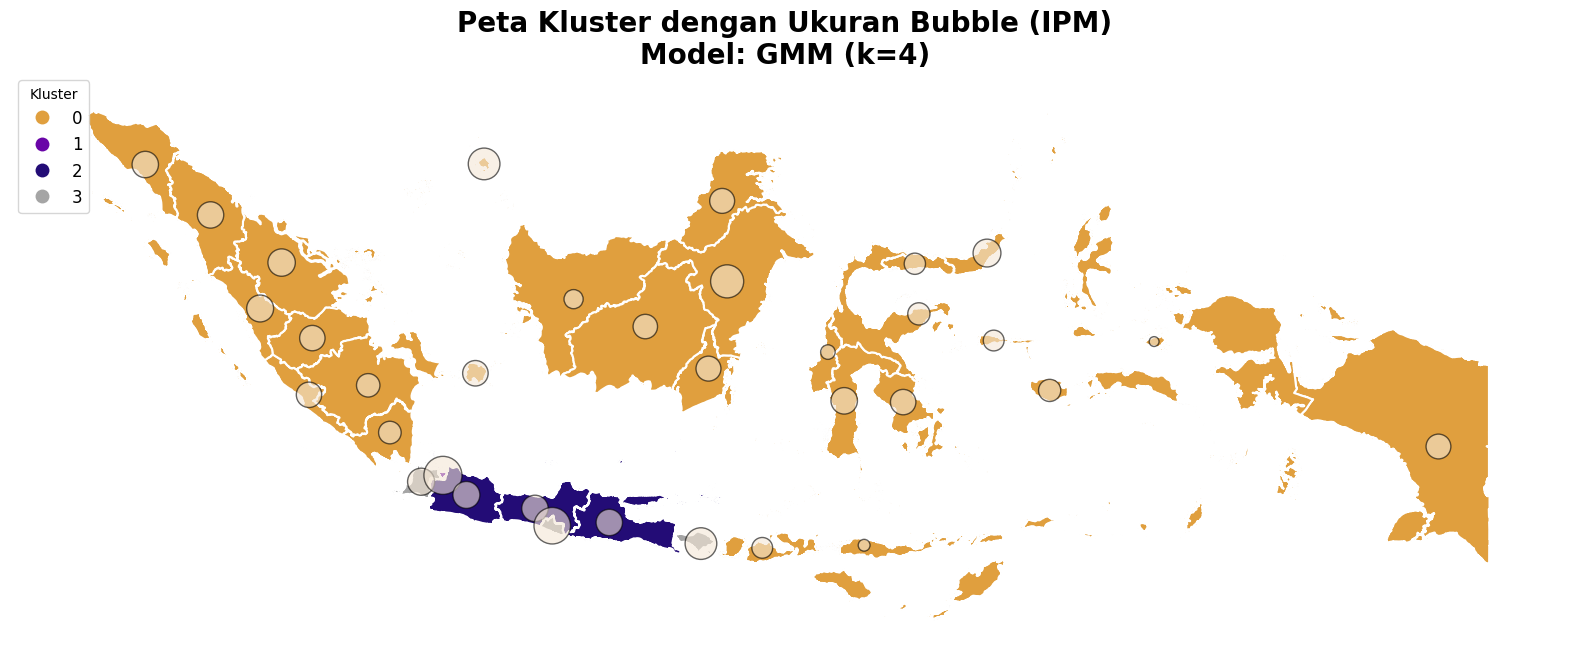


--- Analisis Selesai ---


In [10]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import warnings

warnings.filterwarnings('ignore')

# --- PENGATURAN AWAL ---
FILE_DATA = "C:/Uner/Lomba/Arsen/Data/Data Arsen_L3mao.xlsx"
FILE_SHP = "C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp" 
KOLOM_WILAYAH_PETA = 'NAME_1'
N_COMPONENTS_PCA = 3
CUSTOM_COLORS = ['#E09F3E', '#6905A7', '#230C76', '#A5A5A5'] 
BORDER_COLOR = 'white'
BORDER_LINEWIDTH = 1.5

# --- PENGATURAN UKURAN BUBBLE ---
UKURAN_BUBBLE_MIN = 50
UKURAN_BUBBLE_MAKS = 750

print("--- 1, 2, 3. Memuat, Memproses, dan Melakukan Clustering Data ---")
try:
    df_original = pd.read_excel(FILE_DATA)
except Exception as e:
    print(f"Error saat membaca file: {e}"); exit()

# Pra-pemrosesan dan Clustering
entity_column = df_original.columns[0]
features = df_original.select_dtypes(include=np.number).columns.tolist()
data_to_cluster = df_original[features]
scaler_robust = RobustScaler()
data_scaled = scaler_robust.fit_transform(data_to_cluster)
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=42)
data_pca = pca.fit_transform(data_scaled)

k_values = [3, 4]
all_labels = {}
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    all_labels[f'KMeans_k{k}'] = kmeans.fit_predict(data_pca)
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    all_labels[f'GMM_k{k}'] = gmm.fit_predict(data_pca)
print("Pemodelan clustering selesai.\n")


print("--- 4. Memulai Visualisasi Bubble Map ---")
try:
    gdf = gpd.read_file(FILE_SHP)
    print("Shapefile berhasil dimuat.")
except Exception as e:
    print(f"Error membaca Shapefile: {e}"); exit()

# Menyiapkan data hasil cluster untuk digabungkan
df_results = df_original.copy()
for model_name, labels in all_labels.items():
    df_results[model_name] = labels

# Membersihkan nama wilayah dan menggabungkan data
gdf[KOLOM_WILAYAH_PETA] = gdf[KOLOM_WILAYAH_PETA].str.upper().str.strip()
df_results[entity_column] = df_results[entity_column].str.upper().str.strip()
merged_gdf = gdf.merge(df_results, left_on=KOLOM_WILAYAH_PETA, right_on=entity_column, how='left')
merged_gdf.dropna(subset=all_labels.keys(), inplace=True)

# Variabel untuk ukuran bubble
VARIABEL_BUBBLE = 'IPM' 
print(f"Variabel yang digunakan untuk ukuran bubble: '{VARIABEL_BUBBLE}'")

if VARIABEL_BUBBLE not in merged_gdf.columns:
    print(f"ERROR: Kolom '{VARIABEL_BUBBLE}' tidak ditemukan."); exit()

# Menggunakan MinMaxScaler untuk mengubah skala ukuran bubble
scaler_bubble = MinMaxScaler(feature_range=(UKURAN_BUBBLE_MIN, UKURAN_BUBBLE_MAKS))
merged_gdf['bubble_size'] = scaler_bubble.fit_transform(merged_gdf[[VARIABEL_BUBBLE]])


# Membuat peta untuk setiap model
for model_name in all_labels.keys():
    k = int(model_name.split('_k')[-1])
    custom_cmap = ListedColormap(CUSTOM_COLORS[:k])
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 15))
    
    # 1. Peta Dasar
    merged_gdf.plot(column=model_name,
                    ax=ax,
                    legend=True,
                    categorical=True,
                    legend_kwds={'title': "Kluster", 'loc': 'upper left', 'fontsize': 12},
                    cmap=custom_cmap,
                    edgecolor=BORDER_COLOR,
                    linewidth=BORDER_LINEWIDTH,
                    missing_kwds={"color": "lightgrey", "label": "Data Hilang"})

    # --- PERBAIKAN POSISI BUBBLE: Menggunakan representative_point() ---
    # Ini memastikan bubble selalu berada di dalam daratan provinsi
    ax.scatter(merged_gdf.geometry.representative_point().x,
               merged_gdf.geometry.representative_point().y,
               s=merged_gdf['bubble_size'],
               alpha=0.6,
               color='#F4E7D6',
               edgecolor='black'
              )
    
    # Pengaturan Judul dan Tampilan
    model_display_name = model_name.replace('_k', ' (k=') + ')'
    ax.set_title(f'Peta Kluster dengan Ukuran Bubble ({VARIABEL_BUBBLE})\nModel: {model_display_name}', fontsize=20, fontweight='bold')
    ax.set_axis_off()
    
    print(f"\nMenampilkan peta untuk model: {model_display_name}...")
    plt.show()

print("\n--- Analisis Selesai ---")